# K-Means vs GMM: Hard vs Soft Clustering

## Introduction

Clustering is an unsupervised learning task where we group
data points without any labels. Two of the most widely used
algorithms are K-Means and Gaussian Mixture Models (GMM).

At a high level, both divide data into K groups. But there is
one fundamental difference:

- **K-Means** uses **hard assignment** — every point belongs
  to exactly one cluster with complete certainty
- **GMM** uses **soft assignment** — every point has a
  probability of belonging to each cluster

This tutorial demonstrates that difference using the Iris
dataset, and shows when each method is more appropriate.

### Dataset: Iris
- 150 flower samples
- 4 features: sepal length, sepal width, petal length,
  petal width
- 3 true species: Setosa, Versicolor, Virginica
- Goal: recover the 3 species without using the labels

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Fixed random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ============================================================
# LOAD AND EXPLORE THE IRIS DATASET
# ============================================================

iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

print("Dataset shape:", X.shape)
print("\nFeature names:")
for name in iris.feature_names:
    print(f"  - {name}")

print("\nClass names:", list(iris.target_names))
print("\nSamples per class:")
print(y.value_counts().sort_index())

print("\nFirst 5 rows:")
print(X.head())

Dataset shape: (150, 4)

Feature names:
  - sepal length (cm)
  - sepal width (cm)
  - petal length (cm)
  - petal width (cm)

Class names: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Samples per class:
target
0    50
1    50
2    50
Name: count, dtype: int64

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


## Step 1: Explore the Data

Before clustering, it helps to visualise the raw data.

The Iris dataset has 4 features, so we cannot plot it directly
in 2D. Instead, we plot pairs of features to get an idea of
the structure.

Key observation:
- Setosa is clearly separated from the other two species
- Versicolor and Virginica overlap slightly
- This overlap is exactly where soft assignment will matter

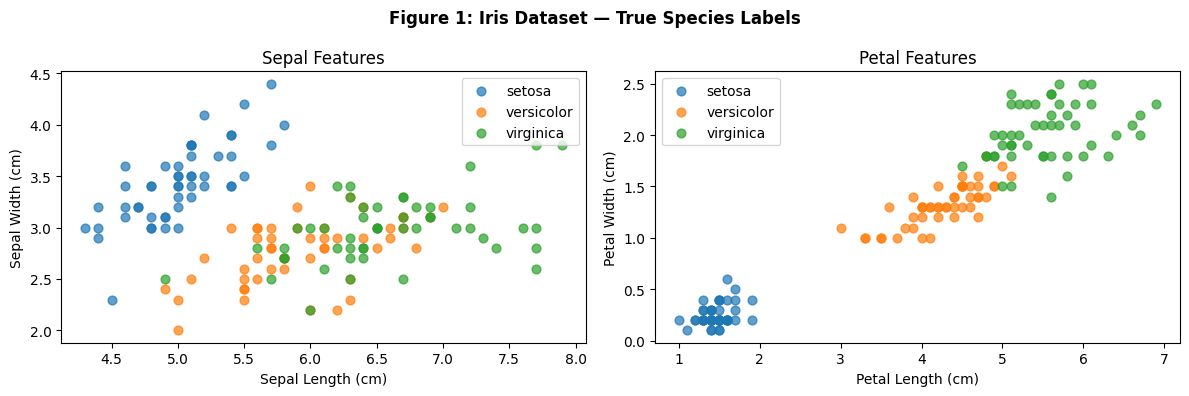

In [3]:
# ============================================================
# VISUALISE RAW DATA
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Sepal features
for k in np.unique(y):
    mask = y == k
    axes[0].scatter(
        X['sepal length (cm)'][mask],
        X['sepal width (cm)'][mask],
        label=iris.target_names[k],
        alpha=0.7, s=40
    )
axes[0].set_title('Sepal Features')
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')
axes[0].legend()

# Plot 2: Petal features
for k in np.unique(y):
    mask = y == k
    axes[1].scatter(
        X['petal length (cm)'][mask],
        X['petal width (cm)'][mask],
        label=iris.target_names[k],
        alpha=0.7, s=40
    )
axes[1].set_title('Petal Features')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend()

plt.suptitle('Figure 1: Iris Dataset — True Species Labels',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig1_raw_data.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Alt-text: Two scatter plots of the Iris dataset coloured by
# true species. Left shows sepal features with some overlap.
# Right shows petal features with clearer separation, especially
# for Setosa. Versicolor and Virginica overlap slightly on both.

## Step 2: Preprocessing

K-Means uses Euclidean distance to assign points to centroids.
If one feature has a much larger scale than another, it will
dominate the distance calculation unfairly.

For example, sepal length ranges from 4.3 to 7.9 cm, while
petal width ranges from 0.1 to 2.5 cm. Without scaling,
sepal length would have more influence just because its
numbers are bigger.

We use StandardScaler to give every feature a mean of 0
and a standard deviation of 1 before clustering.

In [4]:
# ============================================================
# PREPROCESSING — STANDARDSCALER
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling:")
print(f"  Sepal length — mean: {X['sepal length (cm)'].mean():.2f}, "
      f"std: {X['sepal length (cm)'].std():.2f}")
print(f"  Petal width  — mean: {X['petal width (cm)'].mean():.2f}, "
      f"std: {X['petal width (cm)'].std():.2f}")

print("\nAfter scaling:")
print(f"  Feature 0 — mean: {X_scaled[:, 0].mean():.4f}, "
      f"std: {X_scaled[:, 0].std():.4f}")
print(f"  Feature 3 — mean: {X_scaled[:, 3].mean():.4f}, "
      f"std: {X_scaled[:, 3].std():.4f}")

print("\nAll features now on the same scale.")

Before scaling:
  Sepal length — mean: 5.84, std: 0.83
  Petal width  — mean: 1.20, std: 0.76

After scaling:
  Feature 0 — mean: -0.0000, std: 1.0000
  Feature 3 — mean: -0.0000, std: 1.0000

All features now on the same scale.


## Step 3: K-Means Clustering

### How K-Means Works

K-Means finds K clusters by minimising the
Within-Cluster Sum of Squares (WCSS):

    WCSS = sum of squared distances from each point
           to its assigned centroid

The algorithm repeats two steps until nothing changes:

1. **Assignment step**: assign each point to its
   nearest centroid
2. **Update step**: move each centroid to the mean
   of its assigned points

### Hard Assignment

The key limitation is that every point gets a single
definitive label — 0, 1, or 2. There is no way to say
"this point is probably cluster 1 but might be cluster 2".

This is called **hard assignment**.

In [5]:
# ============================================================
# K-MEANS CLUSTERING
# ============================================================

# Fit K-Means with 3 clusters (we know the true K = 3)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
labels_km = kmeans.labels_

print("K-Means Results:")
print(f"  Inertia (WCSS)  : {kmeans.inertia_:.2f}")
print(f"  Silhouette Score: {silhouette_score(X_scaled, labels_km):.3f}")

print("\nCluster sizes:")
unique, counts = np.unique(labels_km, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} points")

print("\nAssignment type: HARD")
print("Sample labels (first 10):", labels_km[:10])
print("Only values 0, 1, 2 — no probabilities")

K-Means Results:
  Inertia (WCSS)  : 191.02
  Silhouette Score: 0.480

Cluster sizes:
  Cluster 0: 96 points
  Cluster 1: 33 points
  Cluster 2: 21 points

Assignment type: HARD
Sample labels (first 10): [1 2 2 2 1 1 1 1 2 2]
Only values 0, 1, 2 — no probabilities


## Step 4: Gaussian Mixture Model (GMM)

### How GMM Works

GMM assumes the data was generated from a mixture of
K Gaussian distributions. Each Gaussian represents
one cluster, with its own mean and shape.

Training uses the Expectation-Maximisation (EM) algorithm:

- **E-step**: for each point, calculate the probability
  it belongs to each Gaussian component
- **M-step**: update the parameters of each Gaussian
  to best explain those probabilities
- Repeat until the solution stops improving

### Soft Assignment

Unlike K-Means, GMM gives each point a probability
for every cluster. A point near the boundary between
two clusters might get:
  - 65% probability of cluster 1
  - 35% probability of cluster 2

This is called **soft assignment** and it reflects
genuine uncertainty honestly.

### Choosing K with BIC

For K-Means we use the elbow method or silhouette score.
For GMM we use the Bayesian Information Criterion (BIC).
Lower BIC = better model.

In [6]:
# ============================================================
# GMM CLUSTERING
# ============================================================

# Fit GMM with 3 components
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_scaled)

# Hard labels (most likely cluster per point)
labels_gmm = gmm.predict(X_scaled)

# Soft probabilities (probability per cluster per point)
probs = gmm.predict_proba(X_scaled)

print("GMM Results:")
print(f"  Silhouette Score: {silhouette_score(X_scaled, labels_gmm):.3f}")
print(f"  BIC             : {gmm.bic(X_scaled):.2f}")
print(f"  AIC             : {gmm.aic(X_scaled):.2f}")

print("\nCluster sizes:")
unique, counts = np.unique(labels_gmm, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} points")

print("\nAssignment type: SOFT")
print("\nSample soft probabilities (first 5 points):")
print(np.round(probs[:5], 3))
print("\nNote: each row sums to 1.0")
print("Rows sum to:", np.round(probs[:5].sum(axis=1), 3))

GMM Results:
  Silhouette Score: 0.475
  BIC             : 841.19
  AIC             : 708.72

Cluster sizes:
  Cluster 0: 98 points
  Cluster 1: 45 points
  Cluster 2: 7 points

Assignment type: SOFT

Sample soft probabilities (first 5 points):
[[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]

Note: each row sums to 1.0
Rows sum to: [1. 1. 1. 1. 1.]


## Step 5: Hard vs Soft — The Core Difference

This is the most important section of the tutorial.

K-Means assigns every point with complete certainty.
GMM tells you how confident it is for each point.

Look at the uncertain points — those near the boundary
between Versicolor and Virginica. K-Means forces a
definitive answer. GMM honestly says "I am not sure."

In real applications this matters enormously. For example:
- In medical diagnosis, a patient near a decision boundary
  should be flagged as uncertain, not forced into a
  definitive diagnosis
- In customer segmentation, some customers genuinely
  belong to multiple segments

In [7]:
# ============================================================
# DEMONSTRATE HARD vs SOFT ASSIGNMENT
# ============================================================

# Maximum probability for each point (GMM confidence)
max_prob = np.max(probs, axis=1)

# Find uncertain points (below 90% confidence)
uncertain_mask = max_prob < 0.90
n_uncertain = uncertain_mask.sum()

print("Hard Assignment (K-Means):")
print(f"  Every point gets label 0, 1, or 2")
print(f"  Unique values: {np.unique(labels_km)}")
print(f"  Certainty: always 100%")

print("\nSoft Assignment (GMM):")
print(f"  Every point gets 3 probabilities summing to 1")
print(f"  Points with confidence below 90%: {n_uncertain}")
print(f"  These are genuinely uncertain boundary points")

print("\nMost uncertain points (lowest max probability):")
uncertain_idx = np.argsort(max_prob)[:8]
for idx in uncertain_idx:
    print(f"  Point {idx:3d}: probs={np.round(probs[idx], 2)}, "
          f"max={max_prob[idx]:.2f}, "
          f"true species={iris.target_names[y[idx]]}")

Hard Assignment (K-Means):
  Every point gets label 0, 1, or 2
  Unique values: [0 1 2]
  Certainty: always 100%

Soft Assignment (GMM):
  Every point gets 3 probabilities summing to 1
  Points with confidence below 90%: 1
  These are genuinely uncertain boundary points

Most uncertain points (lowest max probability):
  Point   8: probs=[0.   0.12 0.88], max=0.88, true species=setosa
  Point  42: probs=[0.   0.08 0.92], max=0.92, true species=setosa
  Point  93: probs=[0.05 0.   0.95], max=0.95, true species=versicolor
  Point  38: probs=[0.   0.04 0.96], max=0.96, true species=setosa
  Point  13: probs=[0.   0.03 0.97], max=0.97, true species=setosa
  Point  60: probs=[0.01 0.   0.99], max=0.99, true species=versicolor
  Point  41: probs=[0. 0. 1.], max=1.00, true species=setosa
  Point  25: probs=[0. 1. 0.], max=1.00, true species=setosa


In [8]:
# ============================================================
# PCA FOR VISUALISATION
# Reduce 4 features to 2D for plotting
# Same approach as Tutorial 3 Problem 3
# ============================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Variance explained by PCA:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.1f}%")
print("\nWe retain most of the information in just 2 dimensions.")

Variance explained by PCA:
  PC1: 73.0%
  PC2: 22.9%
  Total: 95.8%

We retain most of the information in just 2 dimensions.


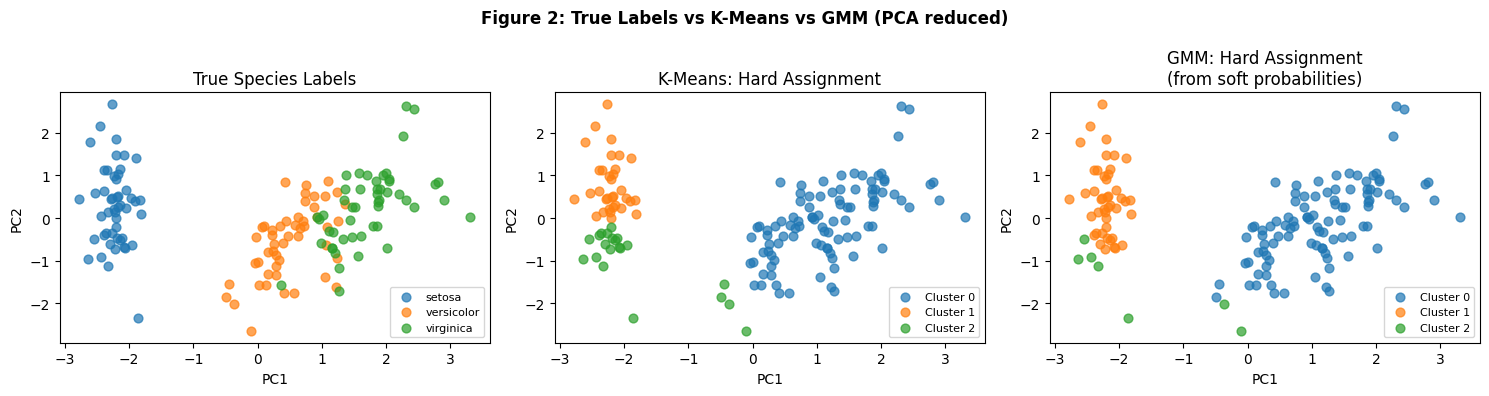

In [9]:
# ============================================================
# VISUALISE CLUSTERING RESULTS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: True labels
for k in np.unique(y):
    mask = y == k
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=iris.target_names[k],
        alpha=0.7, s=40
    )
axes[0].set_title('True Species Labels')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8)

# Plot 2: K-Means
for k in np.unique(labels_km):
    mask = labels_km == k
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f'Cluster {k}',
        alpha=0.7, s=40
    )
axes[1].set_title('K-Means: Hard Assignment')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=8)

# Plot 3: GMM
for k in np.unique(labels_gmm):
    mask = labels_gmm == k
    axes[2].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f'Cluster {k}',
        alpha=0.7, s=40
    )
axes[2].set_title('GMM: Hard Assignment\n(from soft probabilities)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend(fontsize=8)

plt.suptitle('Figure 2: True Labels vs K-Means vs GMM (PCA reduced)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig2_clustering_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Alt-text: Three scatter plots of Iris data reduced to 2D by PCA.
# Left shows true species — Setosa clearly separate, Versicolor and
# Virginica overlapping slightly. Middle shows K-Means hard clusters.
# Right shows GMM clusters. Both algorithms correctly isolate Setosa
# but differ slightly on the Versicolor/Virginica boundary.

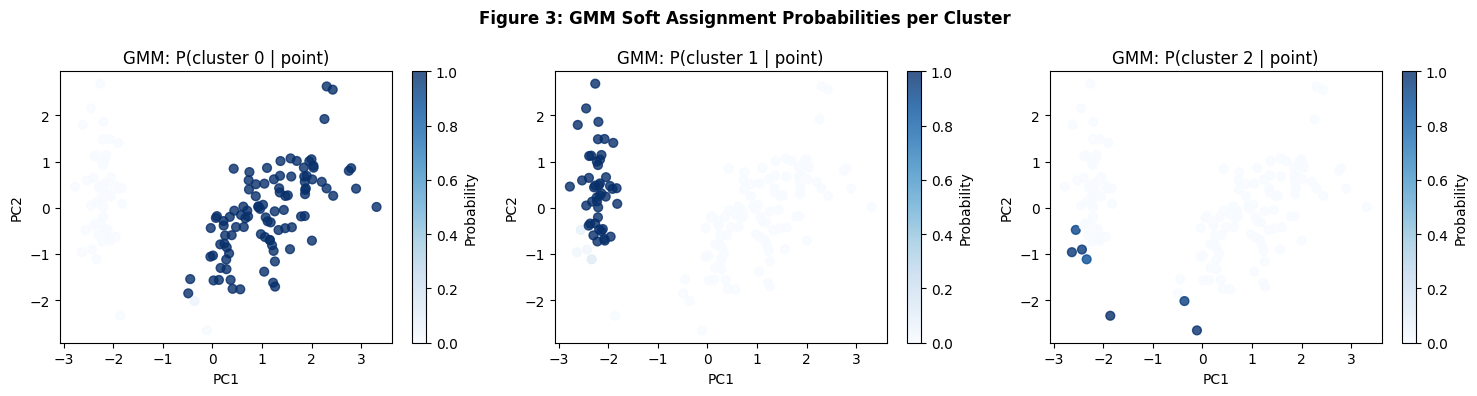

Key insight:
Points in the overlap region get intermediate probabilities.
K-Means cannot represent this uncertainty — it forces
every point to have probability exactly 0 or 1.


In [10]:
# ============================================================
# VISUALISE SOFT PROBABILITIES
# This is what K-Means cannot show
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for k in range(3):
    sc = axes[k].scatter(
        X_pca[:, 0], X_pca[:, 1],
        c=probs[:, k],
        cmap='Blues',
        s=40, alpha=0.8,
        vmin=0, vmax=1
    )
    axes[k].set_title(f'GMM: P(cluster {k} | point)')
    axes[k].set_xlabel('PC1')
    axes[k].set_ylabel('PC2')
    plt.colorbar(sc, ax=axes[k], label='Probability')

plt.suptitle('Figure 3: GMM Soft Assignment Probabilities per Cluster',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig3_soft_probabilities.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Alt-text: Three scatter plots of Iris data in PCA space.
# Each plot shows the probability of belonging to one cluster,
# from 0 (light) to 1 (dark blue). Points in overlap regions
# show intermediate probabilities. K-Means cannot produce
# these plots — every point would be exactly 0 or 1.

print("Key insight:")
print("Points in the overlap region get intermediate probabilities.")
print("K-Means cannot represent this uncertainty — it forces")
print("every point to have probability exactly 0 or 1.")

K=2:  Inertia=222.4,  Silhouette=0.582
K=3:  Inertia=191.0,  Silhouette=0.480
K=4:  Inertia=114.4,  Silhouette=0.385
K=5:  Inertia=91.0,  Silhouette=0.345
K=6:  Inertia=81.6,  Silhouette=0.334
K=7:  Inertia=80.8,  Silhouette=0.266
K=8:  Inertia=64.4,  Silhouette=0.342
K=9:  Inertia=55.7,  Silhouette=0.324
K=10:  Inertia=51.1,  Silhouette=0.335


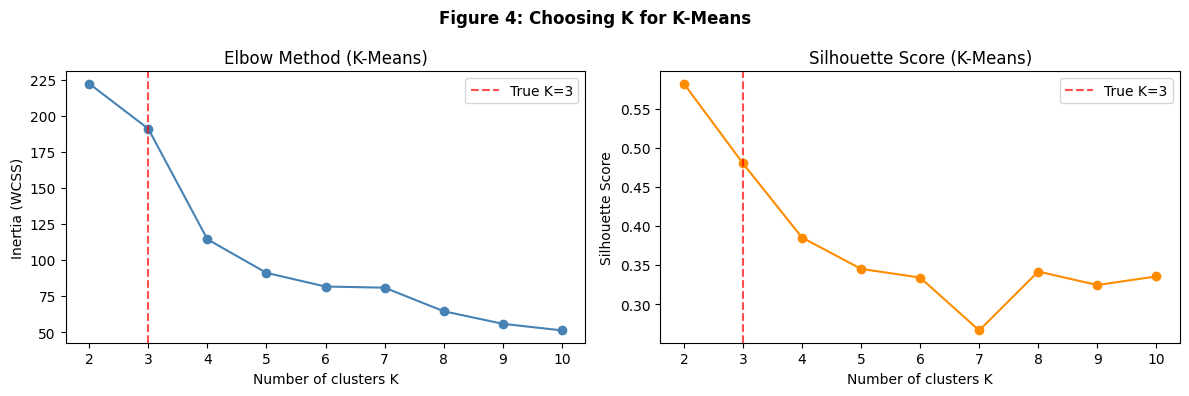


Best K by silhouette: 2


In [11]:
# ============================================================
# CHOOSING K — ELBOW METHOD AND SILHOUETTE (K-MEANS)
# Same pattern as Tutorial 3 Problem 2
# ============================================================

inertias = []
sil_scores_km = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores_km.append(
        silhouette_score(X_scaled, km.labels_)
    )
    print(f"K={k}:  Inertia={km.inertia_:.1f},  "
          f"Silhouette={silhouette_score(X_scaled, km.labels_):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(2, 11), inertias,
             marker='o', color='steelblue')
axes[0].axvline(x=3, color='red', linestyle='--',
                label='True K=3', alpha=0.7)
axes[0].set_title('Elbow Method (K-Means)')
axes[0].set_xlabel('Number of clusters K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend()

axes[1].plot(range(2, 11), sil_scores_km,
             marker='o', color='darkorange')
axes[1].axvline(x=3, color='red', linestyle='--',
                label='True K=3', alpha=0.7)
axes[1].set_title('Silhouette Score (K-Means)')
axes[1].set_xlabel('Number of clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle('Figure 4: Choosing K for K-Means',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig4_choosing_k_kmeans.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Alt-text: Two line plots. Left shows inertia decreasing with K,
# with an elbow visible at K=3. Right shows silhouette score
# peaking at K=3, confirming the true number of species.

print(f"\nBest K by silhouette: "
      f"{list(range(2, 11))[np.argmax(sil_scores_km)]}")

K=2:  BIC=794.7,  AIC=707.4
K=3:  BIC=841.2,  AIC=708.7
K=4:  BIC=849.3,  AIC=671.7
K=5:  BIC=901.5,  AIC=678.8
K=6:  BIC=968.6,  AIC=700.7
K=7:  BIC=955.3,  AIC=642.2
K=8:  BIC=1026.1,  AIC=667.8
K=9:  BIC=1129.4,  AIC=725.9
K=10:  BIC=1100.4,  AIC=651.8


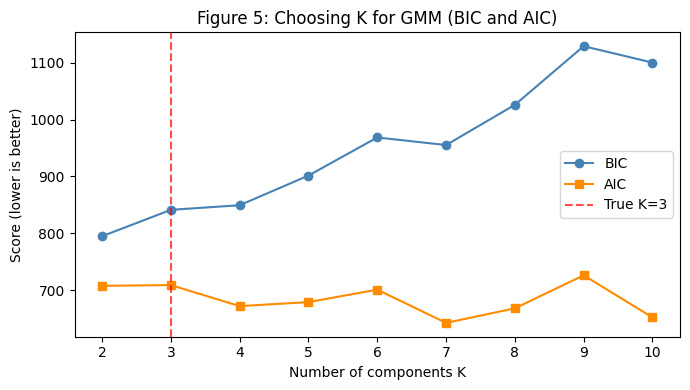


Best K by BIC: 2
Best K by AIC: 7


In [12]:
# ============================================================
# CHOOSING K FOR GMM — BIC AND AIC
# Lower score = better model (penalises complexity)
# ============================================================

bic_scores = []
aic_scores = []

for k in range(2, 11):
    gmm_k = GaussianMixture(n_components=k, random_state=42)
    gmm_k.fit(X_scaled)
    bic_scores.append(gmm_k.bic(X_scaled))
    aic_scores.append(gmm_k.aic(X_scaled))
    print(f"K={k}:  BIC={gmm_k.bic(X_scaled):.1f},  "
          f"AIC={gmm_k.aic(X_scaled):.1f}")

plt.figure(figsize=(7, 4))
plt.plot(range(2, 11), bic_scores,
         marker='o', label='BIC', color='steelblue')
plt.plot(range(2, 11), aic_scores,
         marker='s', label='AIC', color='darkorange')
plt.axvline(x=3, color='red', linestyle='--',
            label='True K=3', alpha=0.7)
plt.title('Figure 5: Choosing K for GMM (BIC and AIC)')
plt.xlabel('Number of components K')
plt.ylabel('Score (lower is better)')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/fig5_choosing_k_gmm.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Alt-text: Line plot with two curves showing BIC and AIC scores
# against number of GMM components K from 2 to 10.
# Both curves reach their minimum at K=3, confirming the true
# number of clusters in the Iris dataset.

print(f"\nBest K by BIC: "
      f"{list(range(2, 11))[np.argmin(bic_scores)]}")
print(f"Best K by AIC: "
      f"{list(range(2, 11))[np.argmin(aic_scores)]}")

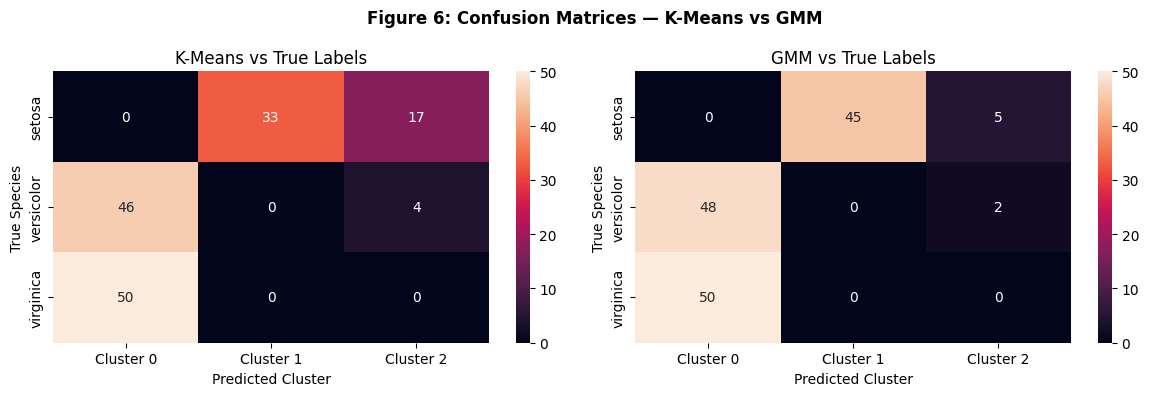


Note: cluster label numbers are arbitrary.
The confusion matrix shows which cluster maps
to which true species.


In [13]:
# ============================================================
# CONFUSION MATRICES
# Compare both methods against true species labels
# Same pattern as Tutorial 3 Problem 1 and 4
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# K-Means confusion matrix
cm_km = confusion_matrix(y, labels_km)
sns.heatmap(cm_km, annot=True, fmt='d',
            ax=axes[0],
            xticklabels=['Cluster 0',
                         'Cluster 1',
                         'Cluster 2'],
            yticklabels=iris.target_names)
axes[0].set_title('K-Means vs True Labels')
axes[0].set_xlabel('Predicted Cluster')
axes[0].set_ylabel('True Species')

# GMM confusion matrix
cm_gmm = confusion_matrix(y, labels_gmm)
sns.heatmap(cm_gmm, annot=True, fmt='d',
            ax=axes[1],
            xticklabels=['Cluster 0',
                         'Cluster 1',
                         'Cluster 2'],
            yticklabels=iris.target_names)
axes[1].set_title('GMM vs True Labels')
axes[1].set_xlabel('Predicted Cluster')
axes[1].set_ylabel('True Species')

plt.suptitle('Figure 6: Confusion Matrices — K-Means vs GMM',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig6_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Alt-text: Two confusion matrix heatmaps. Each shows how the
# predicted clusters map onto the true species labels.
# Larger numbers on the diagonal indicate better performance.
# Both methods correctly identify all Setosa samples.
# Misclassifications occur between Versicolor and Virginica.

print("\nNote: cluster label numbers are arbitrary.")
print("The confusion matrix shows which cluster maps")
print("to which true species.")

In [14]:
# ============================================================
# FINAL COMPARISON SUMMARY
# ============================================================

print("=" * 55)
print("FINAL COMPARISON SUMMARY — IRIS DATASET")
print("=" * 55)

print("\nK-Means:")
print(f"  Silhouette Score : "
      f"{silhouette_score(X_scaled, labels_km):.3f}")
print(f"  Inertia (WCSS)   : {kmeans.inertia_:.2f}")
print(f"  Assignment type  : Hard (0, 1, or 2 only)")
print(f"  Uncertainty info : None")

print("\nGMM:")
print(f"  Silhouette Score : "
      f"{silhouette_score(X_scaled, labels_gmm):.3f}")
print(f"  BIC              : {gmm.bic(X_scaled):.2f}")
print(f"  AIC              : {gmm.aic(X_scaled):.2f}")
print(f"  Assignment type  : Soft (probabilities)")
n_uncertain = np.sum(np.max(probs, axis=1) < 0.9)
print(f"  Uncertain points : {n_uncertain} below 90% confidence")

print("\nWhen to use K-Means:")
print("  - Large datasets where speed matters")
print("  - Clusters are roughly equal in size")
print("  - You only need cluster labels, not probabilities")

print("\nWhen to use GMM:")
print("  - Clusters may overlap")
print("  - You need uncertainty estimates per point")
print("  - Clusters may have different shapes or sizes")

print("\nKey insight:")
print("  Both algorithms find similar hard boundaries here.")
print("  GMM additionally quantifies uncertainty honestly.")
print("  For the overlapping Versicolor/Virginica region,")
print("  soft assignment gives genuinely useful information.")

FINAL COMPARISON SUMMARY — IRIS DATASET

K-Means:
  Silhouette Score : 0.480
  Inertia (WCSS)   : 191.02
  Assignment type  : Hard (0, 1, or 2 only)
  Uncertainty info : None

GMM:
  Silhouette Score : 0.475
  BIC              : 841.19
  AIC              : 708.72
  Assignment type  : Soft (probabilities)
  Uncertain points : 1 below 90% confidence

When to use K-Means:
  - Large datasets where speed matters
  - Clusters are roughly equal in size
  - You only need cluster labels, not probabilities

When to use GMM:
  - Clusters may overlap
  - You need uncertainty estimates per point
  - Clusters may have different shapes or sizes

Key insight:
  Both algorithms find similar hard boundaries here.
  GMM additionally quantifies uncertainty honestly.
  For the overlapping Versicolor/Virginica region,
  soft assignment gives genuinely useful information.


## Conclusion

This tutorial compared K-Means and GMM on the Iris dataset.

### Key Takeaways

1. **Hard vs Soft**: K-Means forces every point into exactly
   one cluster. GMM gives probabilities — reflecting genuine
   uncertainty at cluster boundaries.

2. **Choosing K**: Use the elbow method or silhouette score
   for K-Means. Use BIC or AIC for GMM.

3. **Performance**: On the Iris dataset both achieve similar
   hard-assignment accuracy. The difference is that GMM
   honestly flags uncertain boundary points.

4. **When to choose GMM**: When clusters overlap, when you
   need confidence scores, or when cluster shapes are
   not spherical.

5. **When to choose K-Means**: When speed matters, when
   clusters are well-separated, or when you only need
   hard labels.

### Limitations

- Both methods require K to be specified in advance
- Both can converge to local optima — run multiple times
- Neither handles non-linear cluster shapes well
- GMM can overfit with small datasets

### References

- Bishop, C.M. (2006). Pattern Recognition and Machine
  Learning. Springer. Chapters 9 and 13.
- MacQueen, J. (1967). Some methods for classification and
  analysis of multivariate observations.
- Dempster, A.P. et al. (1977). Maximum likelihood from
  incomplete data via the EM algorithm.
- scikit-learn: sklearn.cluster.KMeans documentation
- scikit-learn: sklearn.mixture.GaussianMixture documentation